In [1]:
from vmc_ising2 import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    get_eval_set,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd
from itertools import chain
import lattice_symmetries as ls

import scipy
import scipy.sparse
import scipy.sparse.linalg

from kagome_round import get_kagome36
from misc_utils import smooth

from datetime import datetime

time_format = "%Y_%m_%d_%H_%M_%S"

Running dilated_nns_xors.py


In [2]:
# load_tasks = ["80", "84", "85", "86", "87"]
# load_tasks = ["80", "88", "89", "92", "93", "94", "95", "96", "97", "98", "100", "101"]
load_tasks = ["0", "1", "5", "4", "6", "7"]
df = (
    read_jsonl_to_df(
        chain(*[list(output_dir.glob(f"{task}/results.jsonl")) for task in load_tasks])
        #   + list(output_dir.glob("58/results.jsonl"))
    )
    .fillna(keep_serializable(default_config))
    .fillna({"run": 0})
    .assign(
        current_timestamp=lambda df: df["current_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
        start_timestamp=lambda df: df["start_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
    )
    # .assign(
    #     n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
    #         "cumsum"
    #     )
    # )
)

/vol/tcm10/ischurov/frustrations-eda/misc_utils.py:205: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dataframes).reset_index(drop=True)


In [3]:
df.query('task_id == 5 and not warm_up')['sign_overlap'].max()

0.9965581704392747

In [4]:
df.query('task_id == 5')['step'].max()

50001

In [5]:
df.query('energy_delta < 0')

,vmc.outer_sample_size,vmc.inner_sample_size,vmc.inner_epochs,vmc.max_steps,vmc.lr,vmc.batch_size,vmc.weight_decay,vmc.eval_set_max_size,vmc.device,system.lattice,...,n_connected_components,largest_connected_component_size,log_prob_fn.split_group_res_conv_net.extend_filter1,log_prob_fn.split_group_res_conv_net.filter_size,log_prob_fn.split_group_res_conv_net.channels,log_prob_fn.split_group_res_conv_net.res_blocks,log_prob_fn.split_group_res_conv_net.additional_generators,log_prob_fn.invariant_res_cnn.resnet_blocks,log_prob_fn.invariant_res_cnn.resnet_block_depth,log_prob_fn.invariant_res_cnn.hidden_channels
10669,20000,4000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,8.0,324144.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
10670,20000,4000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,8.0,324144.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
10671,20000,4000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,8.0,324144.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
10672,20000,4000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,8.0,324144.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
10677,20000,4000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,8.0,324144.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155725,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4957954.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
155742,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4957954.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
155743,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4957954.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
161631,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4464193.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None


In [6]:
datetime.timedelta(days=3) / df.query('not warm_up').groupby("task_id").apply(
    lambda df_group: df_group.assign(
        current_timestamp_diff=lambda x: x["current_timestamp"].diff()
    )
).reset_index(drop=True).groupby('task_id')['current_timestamp_diff'].mean().iloc[-1]

AttributeError: type object 'datetime.datetime' has no attribute 'timedelta'

In [ ]:
df.query("task_id == 7")

,vmc.outer_sample_size,vmc.inner_sample_size,vmc.inner_epochs,vmc.max_steps,vmc.lr,vmc.batch_size,vmc.weight_decay,vmc.eval_set_max_size,vmc.device,system.lattice,...,n_connected_components,largest_connected_component_size,log_prob_fn.split_group_res_conv_net.extend_filter1,log_prob_fn.split_group_res_conv_net.filter_size,log_prob_fn.split_group_res_conv_net.channels,log_prob_fn.split_group_res_conv_net.res_blocks,log_prob_fn.split_group_res_conv_net.additional_generators,log_prob_fn.invariant_res_cnn.resnet_blocks,log_prob_fn.invariant_res_cnn.resnet_block_depth,log_prob_fn.invariant_res_cnn.hidden_channels
153971,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
153972,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
153973,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
153974,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
153975,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166694,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4695608.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
166695,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4695608.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
166696,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4695608.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
166697,50000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,1.0,4695608.0,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None


In [ ]:
df.columns

Index(['vmc.outer_sample_size', 'vmc.inner_sample_size', 'vmc.inner_epochs',
       'vmc.max_steps', 'vmc.lr', 'vmc.batch_size', 'vmc.weight_decay',
       'vmc.eval_set_max_size', 'vmc.device', 'system.lattice', 'system.J2',
       'system.symmetry_basis', 'system.spin_inversion', 'random_seed',
       'log_prob_fn', 'log_prob_fn.invariant_cnn.dilations',
       'log_prob_fn.invariant_cnn.hidden_channels',
       'log_prob_fn.invariant_cnn.kernel_size', 'warm_up',
       'warm_up.vmc_true_signs.overlap', 'warm_up.vmc_true_signs.max_steps',
       'sign_reconstruction', 'sign_reconstruction.annealing.number_sweeps',
       'sign_reconstruction.annealing.repetitions',
       'sign_reconstruction.extension_steps',
       'sign_reconstruction.full_spin_regularization', 'runs', 'run',
       'amplitude_overlap', 'start_timestamp', 'current_timestamp', 'task_id',
       'git_hash', 'energy_delta', 'true_energy', 'estimated_energy',
       'grad_norm', 'outer_step', 'epoch', 'batch_index', '

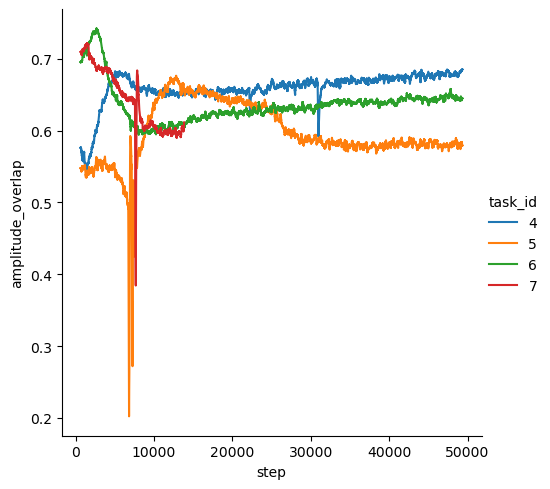

In [8]:
sns.relplot(
    df.query("task_id in [4, 5, 6, 7] and not warm_up")
    .pipe(smooth("amplitude_overlap", 100, ["task_id"])).astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    .pipe(smooth("amplitude_overlap_diff", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 100, ["task_id"]))
    .pipe(smooth("energy_delta", 100, ["task_id"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="amplitude_overlap",
    #hue="warm_up",
    kind="line",
    hue="task_id",
   #col_wrap=3,
)
#plt.ylim(0, 5)

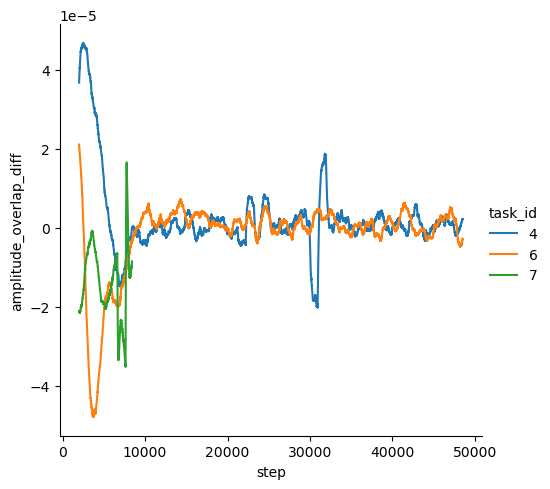

In [22]:
sns.relplot(
    df.query("task_id in [4, 6, 7] and step > 500")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"])).astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    .pipe(smooth("amplitude_overlap_diff", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="amplitude_overlap_diff",
    #hue="warm_up",
    kind="line",
    hue="task_id",
   #col_wrap=3,
)

In [ ]:
df.query('task_id == 6 and warm_up')

,vmc.outer_sample_size,vmc.inner_sample_size,vmc.inner_epochs,vmc.max_steps,vmc.lr,vmc.batch_size,vmc.weight_decay,vmc.eval_set_max_size,vmc.device,system.lattice,...,n_connected_components,largest_connected_component_size,log_prob_fn.split_group_res_conv_net.extend_filter1,log_prob_fn.split_group_res_conv_net.filter_size,log_prob_fn.split_group_res_conv_net.channels,log_prob_fn.split_group_res_conv_net.res_blocks,log_prob_fn.split_group_res_conv_net.additional_generators,log_prob_fn.invariant_res_cnn.resnet_blocks,log_prob_fn.invariant_res_cnn.resnet_block_depth,log_prob_fn.invariant_res_cnn.hidden_channels
103957,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103958,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103959,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103960,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103961,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103962,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103963,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103964,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103965,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103966,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None


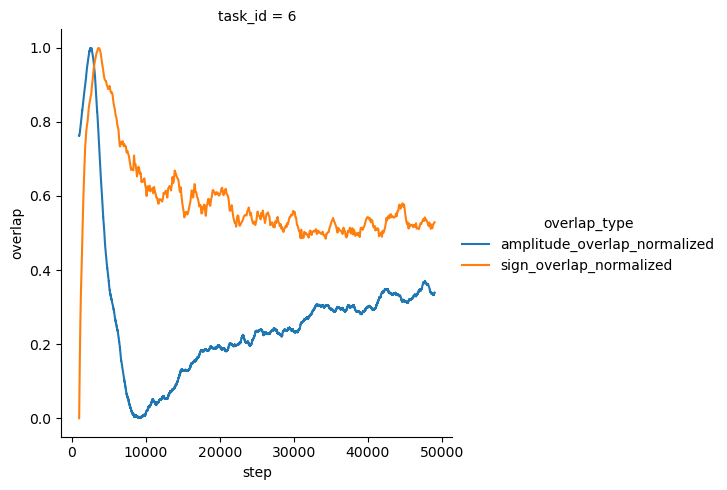

In [ ]:
sns.relplot(
    df.query("task_id == 6")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        amplitude_overlap_normalized=lambda x: (
            x["amplitude_overlap"] - x["amplitude_overlap"].min()
        )
        / (x["amplitude_overlap"].max() - x["amplitude_overlap"].min())
    )
    .assign(
        sign_overlap_normalized=lambda x: (x["sign_overlap"] - x["sign_overlap"].min())
        / (x["sign_overlap"].max() - x["sign_overlap"].min())
    )
    .melt(
        id_vars=["step", "task_id"],
        value_vars=["amplitude_overlap_normalized", "sign_overlap_normalized"],
        var_name="overlap_type",
        value_name="overlap",
    ),
    x="step",
    y="overlap",
    hue="overlap_type",
    kind="line",
    col="task_id",
)

In [ ]:
window = 100
(
    df.query("task_id == 6 and step > 500")
    .pipe(smooth("amplitude_overlap", window, ["task_id"]))
    .pipe(smooth("sign_overlap", window, ["task_id"]))
    .set_index("step")[["amplitude_overlap", "sign_overlap"]]
    .idxmax()
)

amplitude_overlap    2681
sign_overlap         3350
dtype: int64

In [8]:
window = 1000
corrs = []
for lag in range(-300, 300):
    corrs.append(
        {
            "lag": lag,
            "corr": df.query("task_id == 6 and step > 500")
            .pipe(smooth("amplitude_overlap", window, ["task_id"]))
            .pipe(smooth("sign_overlap", window, ["task_id"]))
            .assign(
                sign_overlap_delta=lambda x: x["sign_overlap"].diff(),
                amplitude_overlap_delta=lambda x: x["amplitude_overlap"].diff(),
                amplitude_overlap_delta_shift=lambda x: x[
                    "amplitude_overlap_delta"
                ].shift(lag),
                amplitude_overlap_shift=lambda x: x["amplitude_overlap"].shift(lag),
            )[["sign_overlap", "amplitude_overlap_shift"]]
            .corr()
            .iloc[0, 1],
        }
    )

KeyboardInterrupt: 

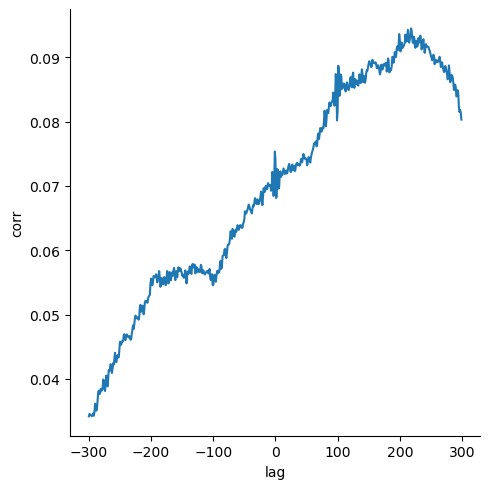

In [ ]:
sns.relplot(pd.DataFrame(corrs), x="lag", y="corr", kind="line")

In [ ]:
pd.DataFrame(dict(x=[1, 2, 3, 4], y=[10, 20, 30, 40])).assign(y=lambda x: x["y"].shift(-1))

,x,y
0,1,20.0
1,2,30.0
2,3,40.0
3,4,NaN
